# 4. Exploring chemical space

**Chemical space** means placing molecules on a map so we can compare them. Each point is one molecule. This is not a map of where molecules are physically located: its axes come from numbers we calculate from their structures. Molecules that look close on one map may be far apart on another if we choose different numbers.

Why make a map at all? A table of numbers is useful, but a plot makes it easier to notice ranges, clusters and unusual molecules. The important first question is always **what do the axes represent?** That tells us what kind of similarity the map can show.

In workbook 3, you calculated molecular descriptors and made a scatter plot. Here we will build on that idea, then try a second representation called a **Morgan fingerprint**. By the end, you should be able to:

- make and interpret a plot using familiar descriptors;
- explain what a molecular fingerprint records;
- compare fingerprints using Tanimoto similarity;
- use PCA to view many fingerprint bits in two dimensions;
- explain why the two plots may tell different stories.

Each section has a short exercise. Try it in the editable cell, then open the solution below it if you need a hint.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, PandasTools, rdFingerprintGenerator
from sklearn.decomposition import PCA

# 1. Choose a small set of drugs

We will reuse the ChEMBL drug table from workbook 3. Each row describes a drug, with columns for information such as its name, SMILES and approval phase. It contains far more drugs than we need for a first plot. By choosing a small subset, we can see and discuss individual groups without a crowded figure.

The path starts with `..` because the file is in the neighbouring `data` folder. `shape` gives the number of rows and columns.

In [38]:
all_drugs = pd.read_csv('../data/chembl_drugs.txt.gz', sep='\t')
all_drugs.shape

(11442, 29)

We will narrow the table in three steps:

1. Keep drugs with a **SMILES string**, because RDKit needs it to build a molecule.
2. Keep **approved drugs** (`DEVELOPMENT_PHASE == 4`), so we work with familiar, real medicines.
3. Keep drugs marked `Y` for the **rule of five**, as in workbook 3. This keeps the example focused on fairly typical small-molecule drugs. It is a teaching choice, **not** a rule for making a chemical-space plot.

Each line below makes the table smaller. These choices define **which drugs our later plots describe**. They do not mean that excluded molecules are unimportant, and conclusions from this notebook should not be taken as conclusions about all of ChEMBL.

In [39]:
drugs = all_drugs[all_drugs['CANONICAL_SMILES'].notna()].copy()
drugs = drugs[drugs['DEVELOPMENT_PHASE'] == 4]
drugs = drugs[drugs['RULE_OF_FIVE'] == 'Y']
len(drugs)

1284

To make the plots easier to read, we will colour just three naming families. A **stem** is a shared piece of a drug name: `sulfa-` appears in some sulfonamide antimicrobials, `-oxacin` in quinolone antibacterials, and `-cillin` in penicillins. `.isin(stems)` asks whether a row belongs to one of these groups.

Why use these labels? We can ask whether drugs with related names also land near one another on a map. The colours are added for us to interpret the plot; they do not determine where a drug is placed. A shared name stem is **not** proof of identical structure or activity.

In [40]:
stems = ['sulfa-', '-oxacin', '-cillin']
drugs = drugs[drugs['USAN_STEM'].isin(stems)].copy()
len(drugs)

52

A SMILES is text that describes a molecular structure. RDKit reads that text and builds a molecule object: atoms and their connections, which its descriptor and fingerprint functions can work with. `PandasTools.AddMoleculeColumnToFrame` puts one such object in the new `ROMol` column for each drug.

A missing SMILES and an unreadable SMILES are different problems: we filtered out missing strings above, and now we drop any strings RDKit could not turn into molecules. The `SYNONYMS` column contains long names, so we keep the part before `(` to make the tables easier to scan. The short name is only a label; the calculations use `ROMol`.

As in the salt example in notebook 3, these calculations preserve the supplied molecular forms. A different preparation policy could change the descriptor values and fingerprints, and therefore the map.

In [41]:
PandasTools.AddMoleculeColumnToFrame(drugs, smilesCol='CANONICAL_SMILES')
drugs = drugs[drugs['ROMol'].notna()].copy()
drugs['name'] = drugs['SYNONYMS'].str.split('(').str[0].str.strip()
drugs[['name', 'USAN_STEM', 'ROMol']].head()

,name,USAN_STEM,ROMol
4,Norfloxacin,-oxacin,<rdkit.Chem.rdchem.Mol object at 0x17e4ef610>
45,Sulfadimethoxine,sulfa-,<rdkit.Chem.rdchem.Mol object at 0x17e4ef450>
72,Temafloxacin,-oxacin,<rdkit.Chem.rdchem.Mol object at 0x17e4efa70>
98,Ciprofloxacin,-oxacin,<rdkit.Chem.rdchem.Mol object at 0x17e4efc30>
112,Nafcillin,-cillin,<rdkit.Chem.rdchem.Mol object at 0x17e4efe60>


We have a small set of drugs now. Before plotting, check how many are in each group. `value_counts()` counts rows with each stem. Similar-sized groups make the colours easier to compare by eye. These counts describe **this selected table**, not how common each family is among all drugs.

In [42]:
drugs['USAN_STEM'].value_counts()

USAN_STEM
sulfa-     18
-oxacin    17
-cillin    17
Name: count, dtype: int64

### Exercise 1

How many `-cillin` drugs are in our table? Use `value_counts()` again, then put `['-cillin']` at the end to select just that count.

In [43]:
# Exercise 1: your code here

<details>
<summary>Solution to exercise 1</summary>

```python
drugs['USAN_STEM'].value_counts()['-cillin']
```

You should get 17. You can also read this number in the count table above.
</details>

# 2. Chemical space using descriptors

Two molecules may be similar in one way but different in another. A **molecular descriptor** is a number calculated from a structure to summarise one aspect of it. Descriptors let us ask specific questions: are these drugs roughly the same size? Do some have more groups that can hydrogen-bond? They also give us values we can sort and plot.

This is our first way to represent a molecule as numbers. We choose a few descriptors that a chemist can interpret, rather than trying to record every bond. Workbook 3 introduced these four:

| Column | What it describes |
| --- | --- |
| `MW` | Molecular weight (g/mol), which is related to molecular size |
| `logP` | Estimated preference for an oily liquid over water; higher usually means less water-friendly |
| `HBD` | Number of groups that can donate a hydrogen bond |
| `HBA` | Number of groups that can accept a hydrogen bond |

`logP` here is an RDKit **estimate**, not an experimental measurement for these drugs. HBD and HBA count opportunities to form hydrogen bonds; neither number alone tells us exactly how a drug behaves in water or in the body.

A descriptor is a **summary**, not a complete drawing of a molecule. For example, ethanol (`CCO`) and dimethyl ether (`COC`) have the same molecular formula and MW, but their atoms are connected differently. Ethanol has an O–H group that can donate a hydrogen bond; dimethyl ether does not. One descriptor cannot distinguish every important difference. First, calculate two descriptors for ethanol:

In [44]:
ethanol = Chem.MolFromSmiles('CCO')
print('Ethanol MW:', round(Descriptors.MolWt(ethanol), 1))
print('Ethanol logP:', round(Descriptors.MolLogP(ethanol), 3))

Ethanol MW: 46.1
Ethanol logP: -0.001


Ethanol's calculated logP is very close to zero. The result belongs to **one molecule**; it says nothing yet about our drug groups. We want the same calculations for every drug so we can compare them. As in workbook 3, `.map()` calls a descriptor function once for each molecule in the `ROMol` column. Each result goes into a new table column.

In [45]:
drugs['MW'] = drugs['ROMol'].map(Descriptors.MolWt)
drugs['logP'] = drugs['ROMol'].map(Descriptors.MolLogP)
drugs['HBD'] = drugs['ROMol'].map(Descriptors.NumHDonors)
drugs['HBA'] = drugs['ROMol'].map(Descriptors.NumHAcceptors)
drugs[['name', 'USAN_STEM', 'MW', 'logP', 'HBD', 'HBA']].head()

,name,USAN_STEM,MW,logP,HBD,HBA
4,Norfloxacin,-oxacin,319.336,1.2683,2,4
45,Sulfadimethoxine,sulfa-,310.335,0.8768,2,7
72,Temafloxacin,-oxacin,417.387,2.9043,2,4
98,Ciprofloxacin,-oxacin,331.347,1.5833,2,4
112,Nafcillin,-cillin,414.483,2.4838,2,5


The table shows that drugs do not all have the same numbers. MW and logP can have decimal values, while HBD and HBA are whole-number counts. Comparing these columns gives us a quick picture of the range of properties in our **selected** drugs.

Notice that our rule-of-five filter has already restricted which molecular weights can appear. If we had kept every molecule in ChEMBL, the range could be different. One easy first question is: how light and how heavy are the molecules in this set?

### Exercise 2

Find the smallest and largest molecular weights in our table. Use `.min()` and `.max()` on the `MW` column, just as you did with columns in workbook 3.

In [46]:
# Exercise 2: your code here

<details>
<summary>Solution to exercise 2</summary>

```python
print('Smallest MW:', round(drugs['MW'].min(), 1))
print('Largest MW:', round(drugs['MW'].max(), 1))
```

These numbers tell us the range of molecular weights in **this filtered set**, not in all drugs.
</details>

# 3. Plot two descriptors

A **scatter plot** puts one dot at each molecule's `(MW, logP)` values. A dot farther right has higher molecular weight; a dot higher up has higher calculated logP. For example, two points at the same height have similar logP even if their molecular weights differ. This is a useful first map because both axes have meanings we already know.

Colouring the three name stems lets us ask a second question: do their MW and logP ranges overlap, or does one family tend to occupy a different part of this particular map? We will keep the same colours in both main plots so that comparison is easier.

In the code below, `stem_colours` pairs each stem with a colour. The `for` loop repeats the same drawing step once for each stem; `group` is just that stem's rows. You do not need to write a new loop in the exercises.

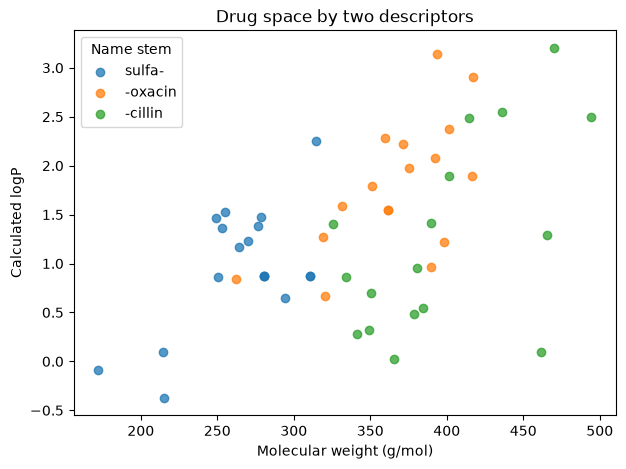

In [47]:
stem_colours = {'sulfa-': 'tab:blue', '-oxacin': 'tab:orange', '-cillin': 'tab:green'}
fig, ax = plt.subplots(figsize=(7, 5))
for stem in stems:
    group = drugs[drugs['USAN_STEM'] == stem]
    ax.scatter(group['MW'], group['logP'], label=stem, color=stem_colours[stem], alpha=0.75)
ax.set_xlabel('Molecular weight (g/mol)')
ax.set_ylabel('Calculated logP')
ax.set_title('Drug space by two descriptors')
ax.legend(title='Name stem')
plt.show()

**What can we learn?** We can see the range of MW and logP, spot unusually high or low values, and see whether the coloured groups overlap. If two dots are close, those two drugs have similar values for **these two descriptors**.

**What can we not learn?** The dots do not show how atoms are connected. Two drugs at nearly the same position may have very different structures or effects. We also cannot tell from this plot whether a difference is caused by the naming family, by our choice of filters, or by some other feature of the molecules.

### Exercise 3

Try a different pair of descriptors. Use `drugs.plot.scatter(x='HBD', y='HBA')`, as in workbook 3. Why might several drugs land on exactly the same point?

In [48]:
# Exercise 3: your code here

<details>
<summary>Solution to exercise 3</summary>

```python
drugs.plot.scatter(x='HBD', y='HBA', alpha=0.5)
```

Both axes are whole-number counts. Different molecules can have the same pair of counts, so their points sit on top of one another.
</details>

# 4. Describe structure with Morgan fingerprints

The descriptor plot does not show which atoms are connected. Two molecules can have similar MW and logP but different structures. If our question is **which molecules contain similar local arrangements of atoms?**, we need a representation that pays more attention to those connections.

A **Morgan fingerprint** is like a small barcode for a molecule. Imagine starting at each atom and looking at its neighbours, then at the neighbours of those neighbours. RDKit turns the local arrangements it finds into a fixed-length row of `0`s and `1`s, also called **bits**. A bit set to `1` means at least one local arrangement was recorded at that position. Similar molecules often share several set bits because they share some local arrangements.

We will use `radius=2`, so RDKit looks up to two bonds away from each starting atom, and `fpSize=256`, so every barcode has 256 positions. We chose a short fingerprint that is easy to inspect in a lesson. Each position is a computer code, **not** a named chemical group: different arrangements can even end up at the same position. A `1` records presence, not how many times the arrangement occurs.

This gives us a different view from MW or logP. It says something about local structure, but it does **not** directly measure size, water solubility or biological activity. First, make a fingerprint for ethanol:

In [49]:
fingerprint_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=256)
ethanol_bits = fingerprint_generator.GetFingerprintAsNumPy(ethanol)
print('First 20 bits:', ethanol_bits[:20])
print('Number of 1 bits:', ethanol_bits.sum())

First 20 bits: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Number of 1 bits: 6


Ethanol has only a few `1`s among its 256 positions. The first 20 happen to be `0`, but that does not mean ethanol has no local patterns: its set bits are elsewhere in the row. The number of set bits is **not** a count of atoms or bonds.

Now do the same for every drug. `.map()` runs the fingerprint function on each molecule, just as it ran the descriptor functions earlier. We put the resulting rows together into a **matrix** (a table of numbers). One row is one drug; each of the 256 columns is the same fingerprint position for every drug. Giving all molecules the same set of columns lets us compare their rows and pass the complete table to PCA.

In [50]:
fingerprints = drugs['ROMol'].map(fingerprint_generator.GetFingerprintAsNumPy)
fingerprint_matrix = np.array(fingerprints.to_list())
print('Rows (drugs), columns (bits):', fingerprint_matrix.shape)

Rows (drugs), columns (bits): (52, 256)


### Exercise 4

How many `1`s are in the **first drug's** fingerprint? `fingerprint_matrix[0]` is its row. Use `.sum()` to count the `1`s, as we did for ethanol.

In [51]:
# Exercise 4: your code here

<details>
<summary>Solution to exercise 4</summary>

```python
fingerprint_matrix[0].sum()
```

The answer is a count of fingerprint positions, **not** a count of atoms.
</details>

# 5. Compare fingerprints with Tanimoto similarity

The fingerprints contain many bits, but sometimes we want one number describing how similar two bit patterns are. **Tanimoto similarity** is the number of bits set to `1` in both fingerprints divided by the number set in either fingerprint.

A score of **0** means no set bits are shared. A score of **1** means the chosen fingerprints have identical bit patterns. Values in between describe partial overlap. This compares local structural patterns, rather than molecular weight or biological activity. Different molecules can sometimes have identical fingerprints, so a score of 1 does not prove molecular identity.

Unlike a SMARTS search, this comparison does not ask whether one particular functional group is present. It compares the overall fingerprint patterns. Both molecules must use the same fingerprint type and settings.

We already used `GetFingerprintAsNumPy()` to make numerical rows for PCA. For RDKit's similarity function, `GetFingerprint()` provides an RDKit bit-vector object. Both methods use the same generator. Compare ethanol with propan-1-ol and with benzene:

In [ ]:
ethanol_fp = fingerprint_generator.GetFingerprint(ethanol)
propanol_fp = fingerprint_generator.GetFingerprint(Chem.MolFromSmiles('CCCO'))
benzene_fp = fingerprint_generator.GetFingerprint(Chem.MolFromSmiles('c1ccccc1'))

print('Ethanol / propan-1-ol:', DataStructs.TanimotoSimilarity(ethanol_fp, propanol_fp))
print('Ethanol / benzene:', DataStructs.TanimotoSimilarity(ethanol_fp, benzene_fp))

Ethanol and propan-1-ol share several local structural patterns, while ethanol and benzene have no shared set bits in this example. Scores depend on the chosen representation: changing the radius or bit length can change them.

This direct comparison uses all of the fingerprint bits. The next section's PCA plot is a compressed view of those bits, so its visual distances need not tell exactly the same story.

### Exercise 5

Predict the similarity of ethanol's fingerprint to itself, then check it with `DataStructs.TanimotoSimilarity(ethanol_fp, ethanol_fp)`.

In [ ]:
# Exercise 5: your code here

<details>
<summary>Solution</summary>

```python
DataStructs.TanimotoSimilarity(ethanol_fp, ethanol_fp)
```

The result is 1.0 because all of the set bits are shared. This is a fingerprint comparison, not a prediction of biological activity.
</details>

# 6. View fingerprints with PCA

For the first map we simply chose two descriptors—MW and logP—and used them as the axes. A fingerprint is different: each drug has **256 bit values**, far too many to put directly on a two-axis plot. We could choose two bits, but we would ignore almost the whole fingerprint.

**Principal component analysis (PCA)** makes a shorter summary of the data. It looks across all the drugs to find combinations of bits that vary the most. Here, 'vary' simply means that the bit values differ between drugs; a bit that is the same for every drug cannot help separate them. Think of PCA as choosing a new viewing direction that shows as much of the spread between these fingerprint rows as possible. The first direction is **PC1**; the next, different direction is **PC2**. Each drug receives a score on both, giving us two numbers to plot.

PCA uses the fingerprint numbers, **not** the drug names, stems or colours. The coloured groups might separate, overlap or spread out: PCA was not instructed to make them separate. We ask for two components because we want a two-dimensional plot. `fit_transform()` finds these directions and calculates the two scores for each drug, which we save as columns.

In [52]:
pca = PCA(n_components=2)
drugs[['PC1', 'PC2']] = pca.fit_transform(fingerprint_matrix)
drugs[['name', 'PC1', 'PC2']].head()

,name,PC1,PC2
4,Norfloxacin,-2.725298,-1.847086
45,Sulfadimethoxine,3.340597,-1.418194
72,Temafloxacin,-2.848162,-1.995999
98,Ciprofloxacin,-3.110478,-2.226492
112,Nafcillin,0.106047,3.208480


Reducing 256 bits to two scores is useful, but it loses detail. `explained_variance_ratio_` reports how much of the **variation across our fingerprint rows** each PC represents. Adding the two shares tells us how much this flat view captures.

A result of about `0.46` means these two PCs show about **46% of the variation in these fingerprint bits**; the remaining variation is not visible in this plot. It does **not** mean we retained 46% of all chemical knowledge, nor does it tell us how well the plot predicts drug effects. If we selected different drugs or a different fingerprint, the number could change.

In [53]:
print('Share shown by the two PCs:', round(pca.explained_variance_ratio_.sum(), 2))

Share shown by the two PCs: 0.46


Now plot the two new scores. We reuse the same colours, so you can compare this plot with the descriptor plot. Each dot still represents one drug. **Unlike MW or logP, PC1 and PC2 do not each mean one familiar property.** Each axis combines many fingerprint positions, so a point far to the right is not necessarily larger or more lipophilic.

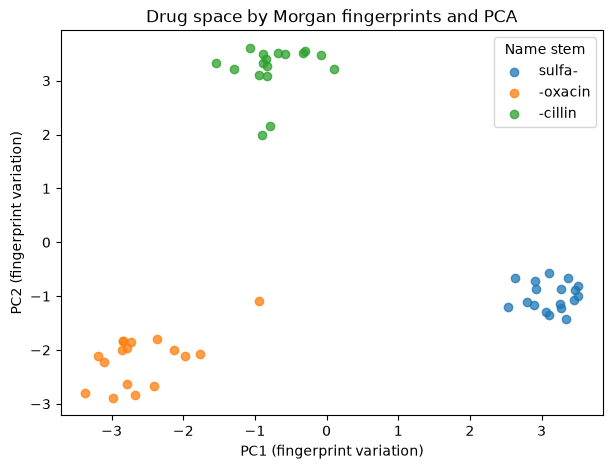

In [54]:
fig, ax = plt.subplots(figsize=(7, 5))
for stem in stems:
    group = drugs[drugs['USAN_STEM'] == stem]
    ax.scatter(group['PC1'], group['PC2'], label=stem, color=stem_colours[stem], alpha=0.75)
ax.set_xlabel('PC1 (fingerprint variation)')
ax.set_ylabel('PC2 (fingerprint variation)')
ax.set_title('Drug space by Morgan fingerprints and PCA')
ax.legend(title='Name stem')
plt.show()

The dots are the **same drugs** as in the MW–logP plot, but their positions can change because we described those drugs in a different way. The descriptor map asks about two overall properties; the fingerprint map asks about many local structural patterns at once. Neither map is the single 'correct' view of chemical space.

A close pair on the PCA plot is close in this **two-dimensional summary**. Its full fingerprints may differ in information the two axes leave out. Likewise, colour overlap does not mean two naming families are chemically identical, and visible separation does not establish different biological activity. Use the plots to form questions about molecules, not to make those conclusions on their own.

### Exercise 6

Look at the two main plots and write two short answers as Python comments below:

1. Can two drugs be close on the MW–logP plot but far apart on the fingerprint PCA plot? Why?
2. Does being close on either plot prove the drugs have the same biological effect?

In [55]:
# Exercise 6: write your two answers here as comments

<details>
<summary>Solution to exercise 6</summary>

1. Yes. MW and logP summarise size and lipophilicity; the fingerprints record local structural patterns. Molecules can match in the first two numbers but differ in structure.
2. No. Neither plot measures biological effect, and each plot leaves out some molecular information.
</details>

# Take-home message

Chemical space depends on **which molecules we include** and **which numbers we use to describe them**. MW and logP give a simple map with easy-to-read axes: it is good for asking about size and lipophilicity. Morgan fingerprints record local structural patterns instead. Tanimoto gives a direct comparison of two full fingerprint bit patterns. PCA lets us view those many bits on two axes, but the axes are harder to interpret and some fingerprint variation is lost.

When you read a chemical-space plot, ask: **What was filtered out? What does one point represent? What do the axes mean? What information is missing?** Nearby points are a starting point for investigating molecules, not proof that they have the same structure or activity.

Original tutorial by Samo Turk (2017); adapted for this workshop.